In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import precession_NS as pre_ns #my version of precession with NS spin precession eqautions
import precession as pre 

In [2]:
theta1, theta2, deltaphi,=(np.array([0.81363956]), np.array([0.94315033]), np.array([0.74294664]))
r0=100.
q=1.
chi1=1.
chi2=1.
k1=10.
k2=10.
u=pre.eval_u(r0,q)

In [4]:


deltachi=pre.eval_deltachi(theta1, theta2, q, chi1, chi2 )
kappa = pre.eval_kappa(theta1=theta1,theta2=theta2,deltaphi=deltaphi,r=r0,q=q,chi1=chi1,chi2=chi2)[0]
chicons= pre_ns.eval_chicons(theta1, theta2, r0, q, chi1, chi2, k1, k2 )[0]
test=pre_ns.inspiral_orbav(deltachi=deltachi, kappa=kappa,chicons=chicons,r=np.linspace(r0, 10,1000),q=q,chi1=chi1,chi2=chi2, k1=k1,k2=k2)


In [ ]:
root=[]
for i in range(0,len(test['deltachi'][0])):
    root.append(pre_ns.deltachiroots(test['kappa'][0][i],test['u'][0][i],test['chicons'][0][i] ,q,chi1,chi2,k1,k2))

In [13]:
for j, g in enumerate(root):
    if len (g)>2: 
        print(j,g)
        break

821 [-0.23768031 -0.0064728   0.0064728   0.23768031]


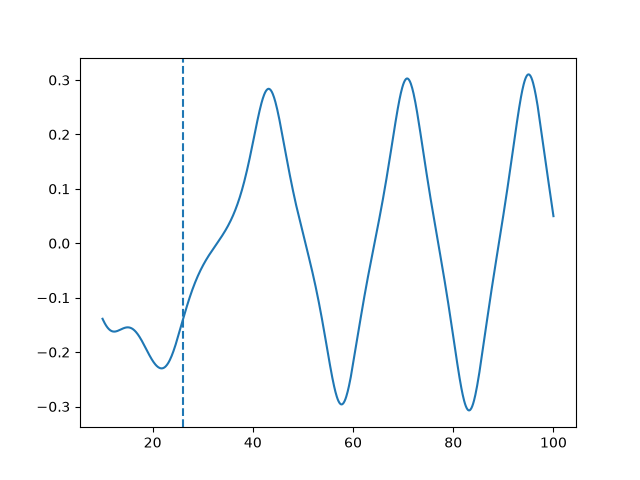

In [16]:
plt.figure()
plt.plot(test['r'][0], test['deltachi'][0])
plt.axvline(test['r'][0][821],ls='--')


Scalar triple product: -0.4239509545252155


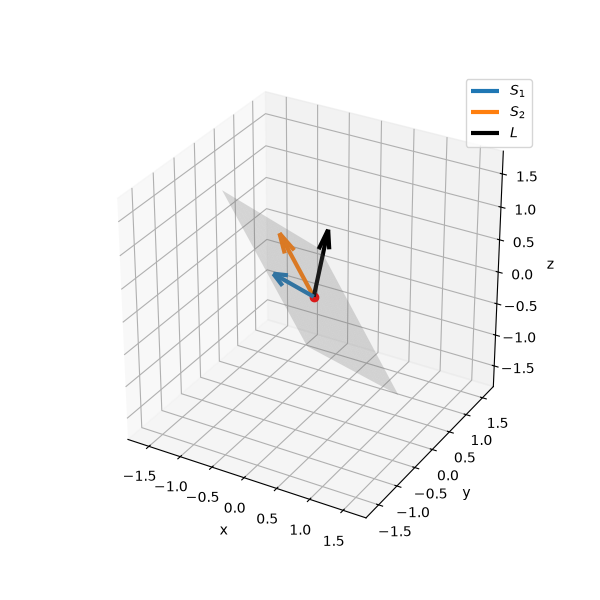

In [21]:

%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
n=821

        
S1 = np.asarray(test['S1h'][n])
S2 = np.asarray(test['S2h'][n])
L  = np.asarray(test['Lh'][n])

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot vectors
ax.quiver(0, 0, 0, *S1, color='C0', linewidth=3, label=r'$S_1$')
ax.quiver(0, 0, 0, *S2, color='C1', linewidth=3, label=r'$S_2$')
ax.quiver(0, 0, 0, *L,  color='k',  linewidth=3, label=r'$L$')

# Plane spanned by S1 and S2
u = np.linspace(-1.2, 1.2, 20)
v = np.linspace(-1.2, 1.2, 20)
U, V = np.meshgrid(u, v)

plane = U[..., None] * S1 + V[..., None] * S2

ax.plot_surface(
    plane[..., 0],
    plane[..., 1],
    plane[..., 2],
    alpha=0.25,
    color='gray',
    edgecolor='none'
)

# Origin
ax.plot(0, 0, 0, 'o', color='red')

# Coplanarity number: scalar triple product
triple = np.dot(S1, np.cross(S2, L))
print("Scalar triple product:", triple)

# Equal-ish limits
all_points = np.vstack([S1, S2, L, plane.reshape(-1, 3)])
max_range = np.max(np.abs(all_points))

ax.set_xlim(-max_range, max_range)
ax.set_ylim(-max_range, max_range)
ax.set_zlim(-max_range, max_range)
ax.set_box_aspect([1, 1, 1])

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend()
